<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/temp/GET_FII_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q

In [143]:
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator,YearLocator

In [144]:
# package import statement
from SmartApi import SmartConnect #or from SmartApi.smartConnect import SmartConnect
import pyotp
from logzero import logger
import time
import os
import urllib
import json
import pandas as pd
import datetime as dt

api_key = 'xOHnB7MG'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"
data = smartApi.generateSession(username, pwd, totp)

if data['status'] == False:
    logger.error(data)

else:
    # login api call
    # logger.info(f"You Credentials: {data}")
    authToken = data['data']['jwtToken']
    refreshToken = data['data']['refreshToken']
    # fetch the feedtoken
    feedToken = smartApi.getfeedToken()
    # fetch User Profile
    res = smartApi.getProfile(refreshToken)
    smartApi.generateToken(refreshToken)
    res=res['data']['exchanges']
#Download Nifty50 Index Data
params = {
           "exchange": "NSE",
           "symboltoken": '99926000',
           "interval": "ONE_DAY",
           "fromdate": (dt.datetime(2020, 9, 21).strftime('%Y-%m-%d %H:%M')),
           "todate": (dt.datetime.today().strftime('%Y-%m-%d %H:%M'))
         }
nifty_data = smartApi.getCandleData(params)
nifty_data_format= pd.DataFrame(nifty_data["data"],
                               columns = ["Date","Open","High","Low","Close","Volume"])
nifty_data_format.set_index("Date",inplace=True)
nifty_data_format.index = pd.to_datetime(nifty_data_format.index)
nifty_data_format.index = nifty_data_format.index.tz_localize(None)

In [145]:
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import yfinance as yf

In [146]:
import numpy as np
import pandas as pd
#from pykalman import KalmanFilter
#import pandas_ta as ta

In [147]:
nif=nifty_data_format

In [148]:
nif.tail(2)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-12,23674.85,23833.15,23556.3,23639.15,0
2026-03-13,23462.50,23492.40,23112.0,23151.10,0


In [149]:
nif.head(2)
nif.reset_index(inplace=True)

In [150]:
fii=pd.read_csv('https://raw.githubusercontent.com/anirbanghoshsbi/.github.io/refs/heads/master/work/ml/fii_dii_sorted.csv')

In [151]:
# Convert both Date columns to datetime
nif["Date"] = pd.to_datetime(nif["Date"])
fii["Date"] = pd.to_datetime(fii["Date"])

# Remove timestamp part from df2
nif["Date"] = nif["Date"].dt.date
fii["Date"] = fii["Date"].dt.date

In [152]:
fii_fig = pd.merge(fii, nif, on="Date", how="inner")

# Change Here

In [153]:
fii_fig['Cash']=fii_fig.FIICash+fii_fig.DIIcash

In [154]:
fii_fig['Cashfut']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signalfutcash']=fii_fig['Cashfut'].ewm(span=22,adjust=False).mean()
fii_fig['signal10futcash']=fii_fig['Cashfut'].ewm(span=10,adjust=False).mean()

# Plot FII minus DII

In [155]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=25,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=10,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [156]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=100, adjust=False).mean()-fii_fig['Cash'].ewm(span=250, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=45,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=20,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [157]:
fii_fig['macd']=fii_fig['DIIcash'].ewm(span=50, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=35,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']

In [158]:
fii_fig['macdx']=fii_fig['FIICash'].ewm(span=50, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signalx']=fii_fig['macdx'].ewm(span=35,adjust=False).mean()
fii_fig['signal10x']=fii_fig['macdx'].ewm(span=10,adjust=False).mean()
fii_fig['histx']=fii_fig['macdx']-fii_fig['signalx']

# Plot FII , DII , Difference comparison

In [159]:
fii_fig['macd']=fii_fig['FIICash'].ewm(span=20, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']


In [160]:
fii_fig['macd_dom']=fii_fig['DIIcash'].ewm(span=20, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal_dom']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['signal_dom_10']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['hist_dom']=fii_fig['macd_dom']-fii_fig['signal_dom']

In [161]:
nif.reset_index(inplace=True)
fii_fig.reset_index(inplace=True)
# Convert the 'Date' column in both DataFrames to the same data type
nif['Date'] = pd.to_datetime(nif['Date'])
fii_fig['Date'] = pd.to_datetime(fii_fig['Date'])

# Merge nif and fii_fig DataFrames on the 'Date' column
merged_df = pd.merge(nif, fii_fig, on='Date')


In [162]:
fii_fig['MA200']=fii_fig.Close.rolling(window=200).mean()
fii_fig['MA20']=fii_fig.Close.rolling(window=20).mean()
fii_fig['MA13']=fii_fig.Close.rolling(window=13).mean()
fii_fig['MA26']=fii_fig.Close.rolling(window=26).mean()
fii_fig['MA12']=fii_fig.Close.ewm(span=12,adjust=False).mean()
# --------------------------
# MACD
# --------------------------
fii_fig["macd_impulse"] = fii_fig["MA12"] - fii_fig["MA26"]

# MACD Signal
fii_fig["macd_signal"] = fii_fig["macd_impulse"].ewm(span=9, adjust=False).mean()

# MACD Histogram
fii_fig["macd_hist"] = fii_fig["macd_impulse"] - fii_fig["macd_signal"]

In [163]:
fii_fig["ema_slope"] = fii_fig["MA13"].diff()
fii_fig["macd_slope"] = fii_fig["macd_hist"].diff()

fii_fig["impulse"] = "blue"

fii_fig.loc[
    (fii_fig["ema_slope"] > 0) & (fii_fig["macd_slope"] > 0),
    "impulse"
] = "green"

fii_fig.loc[
    (fii_fig["ema_slope"] < 0) & (fii_fig["macd_slope"] < 0),
    "impulse"
] = "red"

In [164]:
fii_fig.columns

Index(['index', 'Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash',
       'macdy', 'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10',
       'hist', 'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom',
       'signal_dom', 'signal_dom_10', 'hist_dom', 'MA200', 'MA20', 'MA13',
       'MA26', 'MA12', 'macd_impulse', 'macd_signal', 'macd_hist', 'ema_slope',
       'macd_slope', 'impulse'],
      dtype='object')

# Plot Smart Money (FII)

In [165]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd'], mode='lines', name = 'macd'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=df.Date, y=df['signal'], mode='lines', name = 'signal'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date, y=df['signal10'], mode='lines', name = 'signal10'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="Smart Money And Nifty")

fig.show()

In [166]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
#nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money DII","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd_dom'], mode='lines', name = 'macd'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date,y=df['macd_dom'].rolling(window=10).mean(),mode='lines',name='moving-average 10'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="DII Money And Nifty")

fig.show()

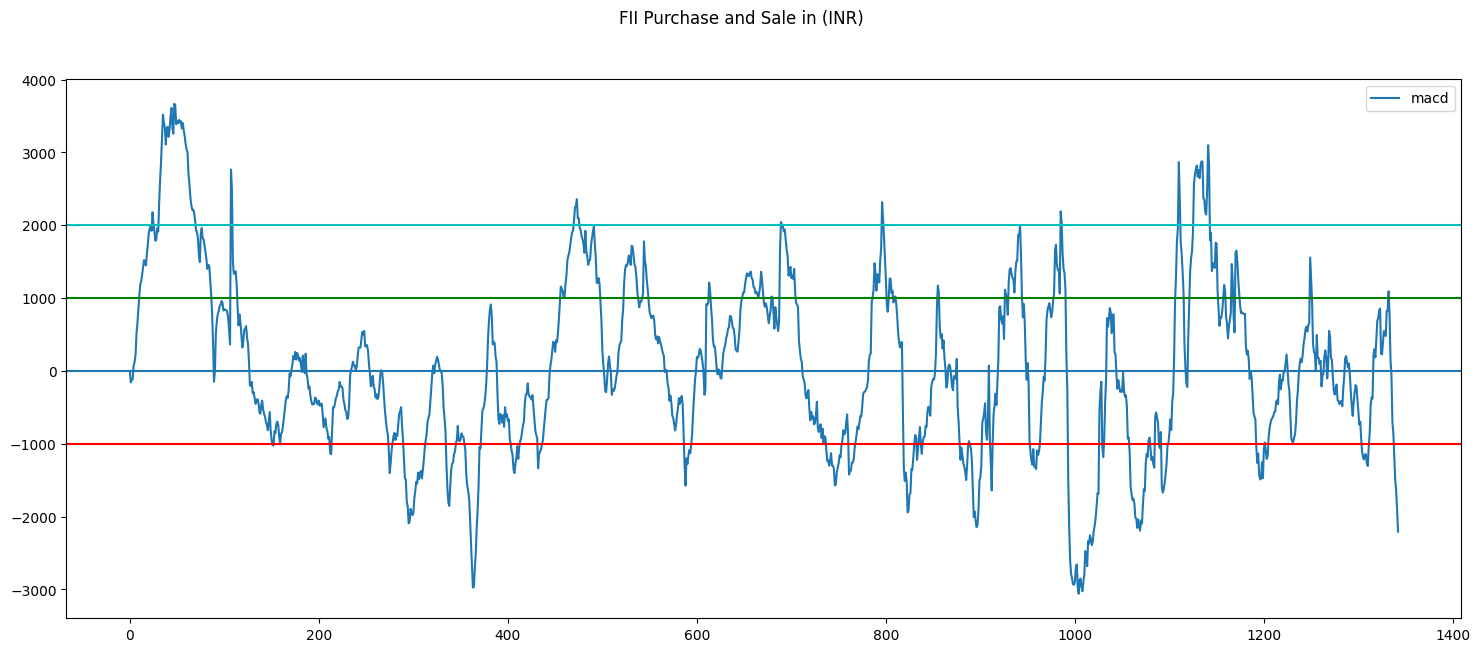

In [167]:
fii_fig['macd'].plot(figsize=(18,7))
plt.axhline(y=0)
plt.axhline(y=1000,color='g')
plt.axhline(y=2000,color='c')
plt.axhline(y=-1000,color='r')
plt.suptitle('FII Purchase and Sale in (INR)')
plt.legend()
plt.show()

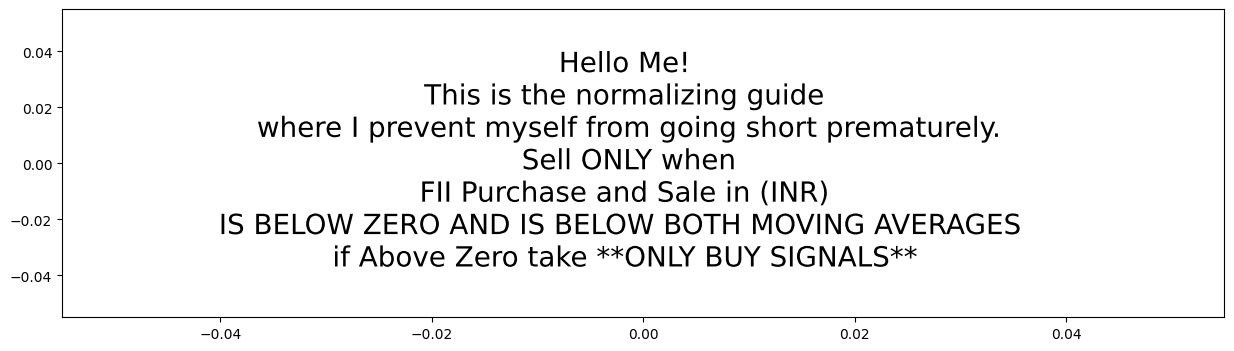

In [168]:
import matplotlib.patheffects as path_effects

fig = plt.figure(figsize=(15, 4))
text = fig.text(0.5, 0.5, 'Hello Me!\n This is the normalizing guide '
                          '\n where I prevent myself from going short prematurely.\n Sell ONLY when'
                           '\nFII Purchase and Sale in (INR)\n'
                           'IS BELOW ZERO AND IS BELOW BOTH MOVING AVERAGES \n'
                           'if Above Zero take **ONLY BUY SIGNALS**',
                ha='center', va='center', size=20)
plt.plot(path_effects=[path_effects.Normal(),path_effects.Normal()])
text.set_path_effects([path_effects.Normal()])


In [169]:
fii_fig['macd_z'] = (
    fii_fig['macd'] - fii_fig['macd'].rolling(252).mean()
) / fii_fig['macd'].rolling(252).std()

In [170]:
fii_fig['macd_regime'] = pd.cut(
    fii_fig['macd_z'],
    bins=[-np.inf,-1,-0.5,0,0.5,1,np.inf],
    labels=[
        'panic_selling',
        'strong_selling',
        'weak_selling',
        'weak_buying',
        'strong_buying',
        'euphoria'
    ]
)

In [171]:
fii_fig['ret_10d'] = (fii_fig['Close'].shift(-5) / fii_fig['Close'] - 1)*100

fii_fig.groupby('macd_regime')['ret_10d'].mean()

,ret_10d
macd_regime,
panic_selling,0.258926
strong_selling,0.190909
weak_selling,0.040442
weak_buying,0.057268
strong_buying,0.146415
euphoria,0.237221


In [172]:
#fii_fig["Date"] = pd.to_datetime(fii_fig["Date"])

regime_slice = (
    fii_fig
    .set_index("Date")
    .loc["2025-04-03":"2025-04-27", ["macd_regime","ret_10d"]]
)

In [173]:
regime_slice

,macd_regime,ret_10d
Date,,
2025-04-03,euphoria,-1.813110
2025-04-04,euphoria,1.851605
2025-04-07,strong_buying,5.755902
2025-04-08,weak_buying,5.838697
2025-04-09,weak_buying,7.707435
2025-04-11,weak_buying,5.864148
2025-04-15,strong_buying,4.288308
2025-04-16,euphoria,3.453911
2025-04-17,euphoria,0.786948


In [174]:
fii_fig['macd_regime'].iloc[-1]

'panic_selling'

In [175]:
fii_fig.groupby('macd_regime')['ret_10d'].median()*100

,ret_10d
macd_regime,
panic_selling,19.025785
strong_selling,37.786061
weak_selling,2.109737
weak_buying,29.092147
strong_buying,14.537697
euphoria,36.348706


In [176]:
fii_fig['trend_regime'] = np.where(
    fii_fig['Close'] > fii_fig['MA20'],
    'above_MA20',
    'below_MA20'
)

In [177]:
pd.pivot_table(
    fii_fig,
    values='ret_10d',
    index='macd_regime',
    columns='trend_regime',
    aggfunc='mean'
)

trend_regime,above_MA20,below_MA20
macd_regime,,
panic_selling,-0.019001,0.355383
strong_selling,0.305871,0.113376
weak_selling,-0.119661,0.184710
weak_buying,-0.051440,0.249271
strong_buying,0.260820,-0.785171
euphoria,0.239200,0.195226


In [178]:
{
  "signal_name": "FII_MACD_Regime_Forward_Return",
  "horizon_days": 10,
  "description": "10-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA50.",
  "trend_variable": "Close_vs_MA50",
  "regimes": {
    "panic_selling": {
      "above_MA50": -0.0002540772,
      "below_MA50": 0.0106831230,
      "interpretation": "Oversold bounce in bear markets."
    },
    "strong_selling": {
      "above_MA50": 0.0026565867,
      "below_MA50": 0.0023052036,
      "interpretation": "Mild positive drift after selling."
    },
    "weak_selling": {
      "above_MA50": 0.0041618008,
      "below_MA50": 0.0066419390,
      "interpretation": "Stabilization bounce."
    },
    "weak_buying": {
      "above_MA50": 0.0034906377,
      "below_MA50": -0.0012507730,
      "interpretation": "Neutral in bull market, weak in bear market."
    },
    "strong_buying": {
      "above_MA50": -0.0011718995,
      "below_MA50": -0.0295404106,
      "interpretation": "Failed rally signal, especially in bear markets."
    },
    "euphoria": {
      "above_MA50": 0.0060588610,
      "below_MA50": 0.0433108930,
      "interpretation": "Momentum continuation or short squeeze."
    }
  },
  "agent_guidance": {
    "bull_market_strategy": {
      "condition": "Close > MA50",
      "preferred_regimes": ["weak_selling", "weak_buying", "euphoria"]
    },
    "bear_market_strategy": {
      "condition": "Close < MA50",
      "preferred_regimes": ["panic_selling", "weak_selling", "euphoria"]
    },
    "avoid_long": [
      "strong_buying"
    ]
  }
}

{'signal_name': 'FII_MACD_Regime_Forward_Return',
 'horizon_days': 10,
 'description': '10-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA50.',
 'trend_variable': 'Close_vs_MA50',
 'regimes': {'panic_selling': {'above_MA50': -0.0002540772,
   'below_MA50': 0.010683123,
   'interpretation': 'Oversold bounce in bear markets.'},
  'strong_selling': {'above_MA50': 0.0026565867,
   'below_MA50': 0.0023052036,
   'interpretation': 'Mild positive drift after selling.'},
  'weak_selling': {'above_MA50': 0.0041618008,
   'below_MA50': 0.006641939,
   'interpretation': 'Stabilization bounce.'},
  'weak_buying': {'above_MA50': 0.0034906377,
   'below_MA50': -0.001250773,
   'interpretation': 'Neutral in bull market, weak in bear market.'},
  'strong_buying': {'above_MA50': -0.0011718995,
   'below_MA50': -0.0295404106,
   'interpretation': 'Failed rally signal, especially in bear markets.'},
  'euphoria': {'above_MA50': 0.006058861,
   'below_MA50': 0.04331

In [179]:
{
  "signal_name": "FII_MACD_Regime_Forward_Return",
  "horizon_days": 5,
  "description": "5-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA20.",
  "trend_variable": "Close_vs_MA20",
  "regimes": {
    "panic_selling": {
      "above_MA20": -0.0024585336,
      "below_MA20": 0.0093548542,
      "interpretation": "Capitulation selling often leads to a strong mean-reversion bounce when the market is already below trend."
    },
    "strong_selling": {
      "above_MA20": 0.0059188999,
      "below_MA20": 0.0006126134,
      "interpretation": "Heavy selling pressure tends to stabilize with mild positive drift, especially when the market remains above trend."
    },
    "weak_selling": {
      "above_MA20": 0.0040891869,
      "below_MA20": 0.0067676796,
      "interpretation": "Profit-taking phase with continued positive drift, often representing healthy pullbacks in trends."
    },
    "weak_buying": {
      "above_MA20": 0.0032938272,
      "below_MA20": -0.0011244001,
      "interpretation": "Small buying pressure supports continuation in uptrends but fails to reverse weak markets."
    },
    "strong_buying": {
      "above_MA20": -0.0050666287,
      "below_MA20": -0.0082905069,
      "interpretation": "Aggressive buying often occurs near exhaustion points and may precede short-term pullbacks."
    },
    "euphoria": {
      "above_MA20": 0.0070438067,
      "below_MA20": 0.0098813739,
      "interpretation": "Momentum phase where liquidity expansion leads to strong continuation or squeeze moves."
    }
  },
  "agent_guidance": {
    "bull_market_strategy": {
      "condition": "Close > MA20",
      "preferred_regimes": ["weak_selling", "weak_buying", "euphoria"]
    },
    "bear_market_strategy": {
      "condition": "Close < MA20",
      "preferred_regimes": ["panic_selling", "weak_selling", "euphoria"]
    },
    "avoid_long": [
      "strong_buying"
    ]
  }
}

{'signal_name': 'FII_MACD_Regime_Forward_Return',
 'horizon_days': 5,
 'description': '5-day forward Nifty return conditioned on FII MACD regime and trend regime relative to MA20.',
 'trend_variable': 'Close_vs_MA20',
 'regimes': {'panic_selling': {'above_MA20': -0.0024585336,
   'below_MA20': 0.0093548542,
   'interpretation': 'Capitulation selling often leads to a strong mean-reversion bounce when the market is already below trend.'},
  'strong_selling': {'above_MA20': 0.0059188999,
   'below_MA20': 0.0006126134,
   'interpretation': 'Heavy selling pressure tends to stabilize with mild positive drift, especially when the market remains above trend.'},
  'weak_selling': {'above_MA20': 0.0040891869,
   'below_MA20': 0.0067676796,
   'interpretation': 'Profit-taking phase with continued positive drift, often representing healthy pullbacks in trends.'},
  'weak_buying': {'above_MA20': 0.0032938272,
   'below_MA20': -0.0011244001,
   'interpretation': 'Small buying pressure supports conti

In [180]:
# MACD crossover conditions
fii_fig['macd_cross_up'] = (
    (fii_fig['macd'] > fii_fig['signal']) &
    (fii_fig['macd'].shift(1) <= fii_fig['signal'].shift(1))
)

fii_fig['macd_cross_down'] = (
    (fii_fig['macd'] < fii_fig['signal']) &
    (fii_fig['macd'].shift(1) >= fii_fig['signal'].shift(1))
)

In [181]:
fii_fig['ret_10d'] = fii_fig['Close'].shift(-20) / fii_fig['Close'] - 1

In [182]:

fii_fig['macd_event'] = np.select(
    [fii_fig['macd_cross_up'], fii_fig['macd_cross_down']],
    ['bullish_cross', 'bearish_cross'],
    default='no_cross'
)

In [183]:
result = fii_fig.groupby('macd_event')['ret_10d'].agg(
    count='count',
    mean='mean',
    median='median',
    win_rate=lambda x: (x > 0).mean()
)

print(result)

               count      mean    median  win_rate
macd_event                                        
bearish_cross     77  0.013384  0.010766  0.645570
bullish_cross     77  0.012566  0.012426  0.576923
no_cross        1169  0.012420  0.011195  0.626476


In [184]:
fii_fig['position'] = 0

fii_fig.loc[fii_fig['macd_cross_up'], 'position'] = 1
fii_fig.loc[fii_fig['macd_cross_down'], 'position'] = 0

fii_fig['position'] = fii_fig['position'].replace(to_replace=0, method='ffill')

In [185]:
fii_fig['ret'] = fii_fig['Close'].pct_change()
fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']
performance = {
    "mean_daily_return": fii_fig['strategy_ret'].mean(),
    "total_return": (1 + fii_fig['strategy_ret']).prod() - 1,
    "win_rate": (fii_fig['strategy_ret'] > 0).mean()
}

print(performance)

{'mean_daily_return': np.float64(0.0005947532449434099), 'total_return': np.float64(1.1054593388584348), 'win_rate': np.float64(0.5398361876396128)}


In [186]:
fii_fig['ma50'] = fii_fig['Close'].rolling(20).mean()
fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']

fii_fig['nifty_above_ma50'] = fii_fig['Close'] > fii_fig['ma50']

In [187]:
fii_fig['long_regime'] = (
    fii_fig['fii_macd_bullish'] &
    fii_fig['nifty_above_ma50']
)
fii_fig['position'] = fii_fig['long_regime'].astype(int)

In [188]:
fii_fig['ret'] = fii_fig['Close'].pct_change()

fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']

In [189]:
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & fii_fig['nifty_above_ma50'],
    'bullish_flow_uptrend',
    'other'
)

print(
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

                      count      mean    median  <lambda_0>
regime                                                     
bullish_flow_uptrend    510  0.002906  0.002185    0.670588
other                   832 -0.000813 -0.000610    0.462185


In [190]:
# 20 DMA
fii_fig['ma20'] = fii_fig['Close'].rolling(20).mean()

# distance from MA20
fii_fig['dist_ma20'] = (fii_fig['Close'] - fii_fig['ma20']) / fii_fig['ma20']

conditions = [
    fii_fig['dist_ma20'] > 0.02,
    fii_fig['dist_ma20'].between(0, 0.02),
    fii_fig['dist_ma20'] < 0
]

choices = [
    'strong_uptrend',
    'weak_uptrend',
    'bearish'
]

fii_fig['trend_regime'] = np.select(conditions, choices, default='neutral')

In [191]:

fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & (fii_fig['dist_ma20'].between(0.03,1)),
    'flow_trend_bullish',
    'other'
)
fii_fig['ret'] = fii_fig['Close'].pct_change()

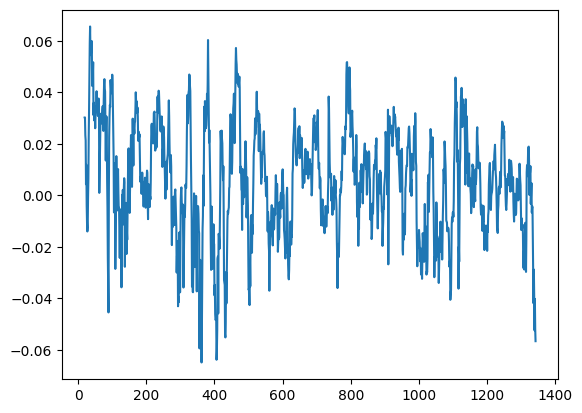

In [192]:
fii_fig['dist_ma20'].plot();

In [193]:
result = (
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

print(result)

                    count      mean    median  <lambda_0>
regime                                                   
flow_trend_bullish    135  0.005190  0.005084    0.785185
other                1207  0.000087  0.000197    0.514073


In [194]:
df = fii_fig[fii_fig['macd'] > 0].copy()

In [195]:


bins = [0,0.02,0.04,0.06,0.08,.1]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [196]:
df['ret'] = df['Close'].pct_change()

In [197]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


              count      mean    median  win_rate
dist_bin                                         
(0.0, 0.02]     255  0.000038  0.000324  0.533333
(0.02, 0.04]    214  0.003760  0.003308  0.714953
(0.04, 0.06]     59  0.005337  0.004975  0.847458
(0.06, 0.08]      2  0.015509  0.015509  1.000000
(0.08, 0.1]       0       NaN       NaN       NaN


In [198]:
df = fii_fig[fii_fig['macd'] <= 0].copy()

In [199]:
bins = [-.1,-0.08,-0.06,-0.04,-0.02,0]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [200]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


                count      mean    median  win_rate
dist_bin                                           
(-0.1, -0.08]       0       NaN       NaN       NaN
(-0.08, -0.06]      3 -0.015791 -0.022212  0.000000
(-0.06, -0.04]     24 -0.011204 -0.011390  0.166667
(-0.04, -0.02]    105 -0.004896 -0.004741  0.285714
(-0.02, 0.0]      274 -0.000531 -0.001553  0.394161


In [201]:
fii_fig["exit_signal"] = fii_fig["Close"] < fii_fig["ma20"]

In [202]:
fii_fig["entry_signal"] = (
    (fii_fig["Close"] > fii_fig["ma20"]) &
    (fii_fig["macd"] > fii_fig['signal10']) &
    #(fii_fig["dist_ma20"] > 0) &
    (fii_fig["impulse"] == "green")
)

In [203]:
position = 0
entry_price = 0

trades = []

for i in range(len(fii_fig)):

    price = fii_fig["Close"].iloc[i]

    if position == 0:

        if fii_fig["entry_signal"].iloc[i]:
            position = 1
            entry_price = price
            entry_date = fii_fig.index[i]

    elif position == 1:

        if fii_fig["exit_signal"].iloc[i]:

            exit_price = price
            exit_date = fii_fig.index[i]

            ret = (exit_price / entry_price) - 1

            trades.append({
                "entry_date": entry_date,
                "exit_date": exit_date,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "return": ret
            })

            position = 0

In [204]:
trades_df = pd.DataFrame(trades)

In [205]:
stats = {
    "trades": len(trades_df),
    "mean_return": trades_df["return"].mean(),
    "median_return": trades_df["return"].median(),
    "win_rate": (trades_df["return"] > 0).mean(),
    "max_gain": trades_df["return"].max(),
    "max_loss": trades_df["return"].min(),
}

print(stats)

{'trades': 41, 'mean_return': np.float64(0.011650288430171091), 'median_return': -0.005466956031966785, 'win_rate': np.float64(0.43902439024390244), 'max_gain': 0.19569215266406337, 'max_loss': -0.04715980955822652}
